## Purpose
This notebook will identify last 3 months best perfomer

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, current_date, date_sub
import configparser
import os
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from grid_chart_util import create_stock_price_grid
from spark_init import initialize_spark
from config_loader import load_config

In [6]:
tablename = "stocksinfp"
earning_table = "stocks_earnings"
# Load configuration details
try:
    url, driver, username, password = load_config()
    print(f"URL: {url}, Driver: {driver}, Username: {username}, Table: {tablename}")
except Exception as e:
    print(f"Error loading config: {e}")
spark = initialize_spark("25BestVolatile")

URL: jdbc:mysql://localhost/stocksdb, Driver: com.mysql.cj.jdbc.Driver, Username: quizadmin, Table: stocksinfp
Error loading config: name 'some_other_param' is not defined


Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/02/17 22:51:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/02/17 22:51:57 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/02/17 22:51:57 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
25/02/17 22:51:57 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
25/02/17 22:51:57 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
25/02/17 22:51:57 WARN Utils: Service 'SparkUI' could not bind on port 4044. Attempting port 4045.
25/02/17 22:51:57 WARN Utils: Service 'SparkUI' could not bind on port 4045. Attempting port 4046.
25/02/17 22:51:57 WARN Utils: Service 'SparkUI' could

In [7]:
stock_df = spark.read.format("jdbc").options(url=url, driver=driver, user=username, password=password, dbtable=tablename).load()
#spark.sparkContext.stop()

In [8]:
# Filter for records in the last 1 year
one_year_ago = date_sub(current_date(), 90)
filtered_df = stock_df.filter(col("Date") >= one_year_ago)
#filtered_df = filtered_df.filter((col("Symbol").isin(['LLY']))) #| (col("Symbol") == 'PANW')
#filtered_df = filtered_df.filter(col("Date").isin(["2024-09-03","2024-08-02","2024-08-05","2024-08-30",
#                                                "2024-07-01","2024-07-02","2024-07-31",
#                                               "2024-06-28","2024-06-05","2024-06-03",
#                                               "2024-05-31","2024-05-30","2024-05-01"]))
# Show the result
filtered_df.show(2, truncate=False)

+----------+------------------+------------------+------------------+------------------+------------------+--------+------+------------------+
|Date      |Open              |High              |Low               |Close             |Adj Close         |Volume  |symbol|price_change      |
+----------+------------------+------------------+------------------+------------------+------------------+--------+------+------------------+
|2024-11-19|226.97999572753906|230.16000366210938|226.66000366210938|228.27999877929688|228.27999877929688|36211800|AAPL  |0.2599945068359375|
|2024-11-19|165.27000427246094|167.10000610351562|163.80999755859375|166.57000732421875|166.57000732421875|5246000 |ABBV  |0.290008544921875 |
+----------+------------------+------------------+------------------+------------------+------------------+--------+------+------------------+
only showing top 2 rows



In [9]:
# Convert Spark DataFrame to Pandas DataFrame
pandas_df = filtered_df.select("date","symbol","close").toPandas()

# Convert all column headers to lowercase
pandas_df.columns = pandas_df.columns.str.lower()
pandas_df['date'] = pd.to_datetime(pandas_df['date'])


# Display the Pandas DataFrame
print(pandas_df.head(2))

        date symbol               close
0 2024-11-19   AAPL  228.27999877929688
1 2024-11-19   ABBV  166.57000732421875


In [10]:
print(pandas_df['close'].dtype)
pandas_df['close'] = pd.to_numeric(pandas_df['close'], errors='coerce')

# Display the Pandas DataFrame
print(pandas_df.head(2))

object
        date symbol       close
0 2024-11-19   AAPL  228.279999
1 2024-11-19   ABBV  166.570007


In [11]:
# Dropping rows where 'close' is NaN (optional, based on your use case)
df = pandas_df.dropna(subset=['close'])

print(df.head(2))

        date symbol       close
0 2024-11-19   AAPL  228.279999
1 2024-11-19   ABBV  166.570007


In [12]:

# Sort the DataFrame by 'symbol' and 'date'
df = df.sort_values(['symbol', 'date'])

# Create a 'year_month' column
df['year_month'] = df['date'].dt.to_period('M')

# Get the current date
current_date = datetime.datetime.now()
current_year_month = pd.Period(current_date, freq='M')

# Function to get first and last rows, handling current month specially
def get_first_last(group):
    group = group.sort_values('date')
    if len(group) == 1 and group['year_month'].iloc[0] == current_year_month:
        return pd.Series({
            'month_start_price': float('nan'),  # We'll fill this later
            'month_end_price': group['close'].iloc[0],
            'month_start_date': group['date'].iloc[0],
            'month_end_date': group['date'].iloc[0],
            'is_current_month': True
        })
    else:
        return pd.Series({
            'month_start_price': group['close'].iloc[0],
            'month_end_price': group['close'].iloc[-1],
            'month_start_date': group['date'].iloc[0],
            'month_end_date': group['date'].iloc[-1],
            'is_current_month': group['year_month'].iloc[0] == current_year_month
        })

# Calculate the monthly price data
monthly_data = df.groupby(['symbol', 'year_month']).apply(get_first_last).reset_index()
#monthly_data = df.groupby(['symbol', 'year_month']).apply(get_first_last).reset_index(drop=True)


# Sort the monthly data by symbol and year_month
monthly_data = monthly_data.sort_values(['symbol', 'year_month'])

# Fill in the start price for the current month if it's NaN
for symbol in monthly_data['symbol'].unique():
    symbol_data = monthly_data[monthly_data['symbol'] == symbol]
    current_month_row = symbol_data[symbol_data['is_current_month'] & symbol_data['month_start_price'].isna()]
    
    if not current_month_row.empty:
        prev_month_row = symbol_data[symbol_data['year_month'] < current_year_month].iloc[-1] if len(symbol_data) > 1 else None
        if prev_month_row is not None:
            monthly_data.loc[current_month_row.index, 'month_start_price'] = prev_month_row['month_end_price']

# Calculate the price increase
monthly_data['monthly_increase'] = monthly_data['month_end_price'] - monthly_data['month_start_price']

# Calculate the percentage increase
monthly_data['monthly_increase_percent'] = (monthly_data['monthly_increase'] / monthly_data['month_start_price']) * 100

# Merge the calculated monthly increase back into the original DataFrame
df = df.merge(
    monthly_data[['symbol', 'year_month', 'monthly_increase', 'monthly_increase_percent', 'month_start_price', 'month_end_price', 'is_current_month']],
    on=['symbol', 'year_month'],
    how='left'
)

# Clean up
df = df.drop('year_month', axis=1)

# Set 'date' as index if desired
df = df.set_index('date')

# Display the results
#print(df[['symbol', 'close', 'monthly_increase', 'monthly_increase_percent', 'month_start_price', 'month_end_price', 'is_current_month']].head(10))

# Optional: If you want to see the monthly increase for each month
print("\nMonthly increase for each month:")
print(monthly_data[['symbol', 'year_month', 'month_start_date', 'month_end_date', 'month_start_price', 'month_end_price', 'monthly_increase', 'monthly_increase_percent', 'is_current_month']].head(10))


Monthly increase for each month:
  symbol year_month month_start_date month_end_date  month_start_price  \
0   AAPL    2024-11       2024-11-19     2024-11-29         228.279999   
1   AAPL    2024-12       2024-12-02     2024-12-31         239.589996   
2   AAPL    2025-01       2025-01-02     2025-01-31         243.850006   
3   AAPL    2025-02       2025-02-03     2025-02-14         228.009995   
4   ABBV    2024-11       2024-11-19     2024-11-29         166.570007   
5   ABBV    2024-12       2024-12-02     2024-12-31         181.770004   
6   ABBV    2025-01       2025-01-02     2025-01-31         179.440002   
7   ABBV    2025-02       2025-02-03     2025-02-14         190.139999   
8    ACB    2024-11       2024-11-19     2024-11-29           4.180000   
9    ACB    2024-12       2024-12-02     2024-12-31           4.630000   

   month_end_price  monthly_increase  monthly_increase_percent  \
0       237.330002          9.050003                  3.964431   
1       250.419998 

/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_65675/2760424660.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_data = df.groupby(['symbol', 'year_month']).apply(get_first_last).reset_index()


In [13]:
# Step 6: Filter the dataframe for the top 25 symbols based on 3-month increases
# For demonstration purposes, we'll consider 'monthly_increase' over the last 3 months.

# Get the current date and calculate the date 3 months ago
current_date = datetime.datetime.now()
three_months_ago = current_date - pd.DateOffset(months=3)

# Filter the monthly data for the last 3 months
last_3_months_data = monthly_data[monthly_data['month_end_date'] > three_months_ago]

# Calculate the cumulative 3-month increase for each symbol
cumulative_increase = last_3_months_data.groupby('symbol').agg({
    'monthly_increase': 'sum',
    'month_start_price': 'first',
    'month_end_price': 'last'
}).reset_index()

cumulative_increase['cumulative_percent_increase'] = (
    (cumulative_increase['month_end_price'] - cumulative_increase['month_start_price']) / 
    cumulative_increase['month_start_price'] * 100
)

# Sort by cumulative percent increase and get the top 25 symbols
top_25_symbols = cumulative_increase.sort_values('cumulative_percent_increase', ascending=False).head(25)

# Filter the original dataframe for these top 25 symbols
df_top_25 = monthly_data[monthly_data['symbol'].isin(top_25_symbols['symbol'])]

# Display the results
print("Top 25 Symbols Based on 3-Month Increase:")
print(top_25_symbols[['symbol', 'cumulative_percent_increase']])

print("\nSample of filtered dataframe (first 10 rows):")
print(df_top_25[['symbol', 'month_start_date','month_start_price', 'month_end_price', 'monthly_increase', 'monthly_increase_percent']].head(10))

# Optional: Save the filtered dataframe to a CSV file
#df_top_25.to_csv('top_25_symbols_3_month_increase.csv', index=True)
#print("\nFiltered dataframe saved to 'top_25_symbols_3_month_increase.csv'")

Top 25 Symbols Based on 3-Month Increase:
    symbol  cumulative_percent_increase
162   RGTI                   801.526789
20    APPS                   411.570237
50    CRNC                   362.626250
94      KC                   353.376880
175   SENS                   289.937124
167     RR                   183.213178
25      BB                   142.127672
145   PLTR                    89.202929
52    CRSR                    88.467372
84    HOOD                    85.244029
161   REAL                    84.953691
116    NET                    77.607138
144   PLBY                    72.566377
168   RXRX                    67.942580
32    BLIN                    59.090906
18     APP                    58.824995
29    BFLY                    56.393444
174   SEDG                    56.330629
59     DDD                    56.146174
44     CLS                    52.107807
2      ACB                    50.956943
63    DOCS                    49.563364
114   MVIS                    48.88889

In [14]:
# Convert 'date' to datetime format and create a 'year_month' column for grouping
df = df_top_25
df['month_start_date'] = pd.to_datetime(df['month_start_date'])
df['year_month'] = df['month_start_date'].dt.to_period('M')

# Convert 'year_month' to string for proper ordering in plot
df['year_month_str'] = df['year_month'].astype(str)

# Fill NaN values
df['monthly_increase'] = df['monthly_increase'].fillna(0.0)

# Ensure 'year_month_str' is treated as categorical with a specific order
df['year_month_str'] = pd.Categorical(df['year_month_str'], categories=sorted(df['year_month_str'].unique()), ordered=True)

# Aggregate data
agg_df = df.groupby(['year_month_str', 'symbol'], observed=False).agg(
    total_monthly_increase=('monthly_increase', 'sum'),
    avg_percentage_increase=('monthly_increase_percent', 'mean')
).reset_index()

# Fill NaN values with 0 in 'monthly_increase' and 'percentage_increase'
agg_df['total_monthly_increase'] = agg_df['total_monthly_increase'].fillna(0)
agg_df['avg_percentage_increase'] = agg_df['avg_percentage_increase'].fillna(0)
agg_df = agg_df[agg_df['total_monthly_increase'] > 0]
print(agg_df)

   year_month_str symbol  total_monthly_increase  avg_percentage_increase
0         2024-11    ACB                0.370000                 8.851684
1         2024-11    APP               15.559998                 4.844484
2         2024-11   APPS                0.230000                19.008265
3         2024-11     BB                0.220000                 9.361704
4         2024-11   BFLY                0.240000                 7.868853
..            ...    ...                     ...                      ...
95        2025-02   RXRX                3.280000                45.241376
96        2025-02   SEDG                3.000001                22.455098
97        2025-02   SENS                0.345000                38.547490
98        2025-02   SMCI               21.059999                78.435751
99        2025-02   SNOW                5.060013                 2.772002

[75 rows x 4 columns]


/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_65675/1769079552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_start_date'] = pd.to_datetime(df['month_start_date'])
/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_65675/1769079552.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_month'] = df['month_start_date'].dt.to_period('M')
/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_65675/1769079552.py:7: SettingWithCopyWarning: 
A value is trying to be s

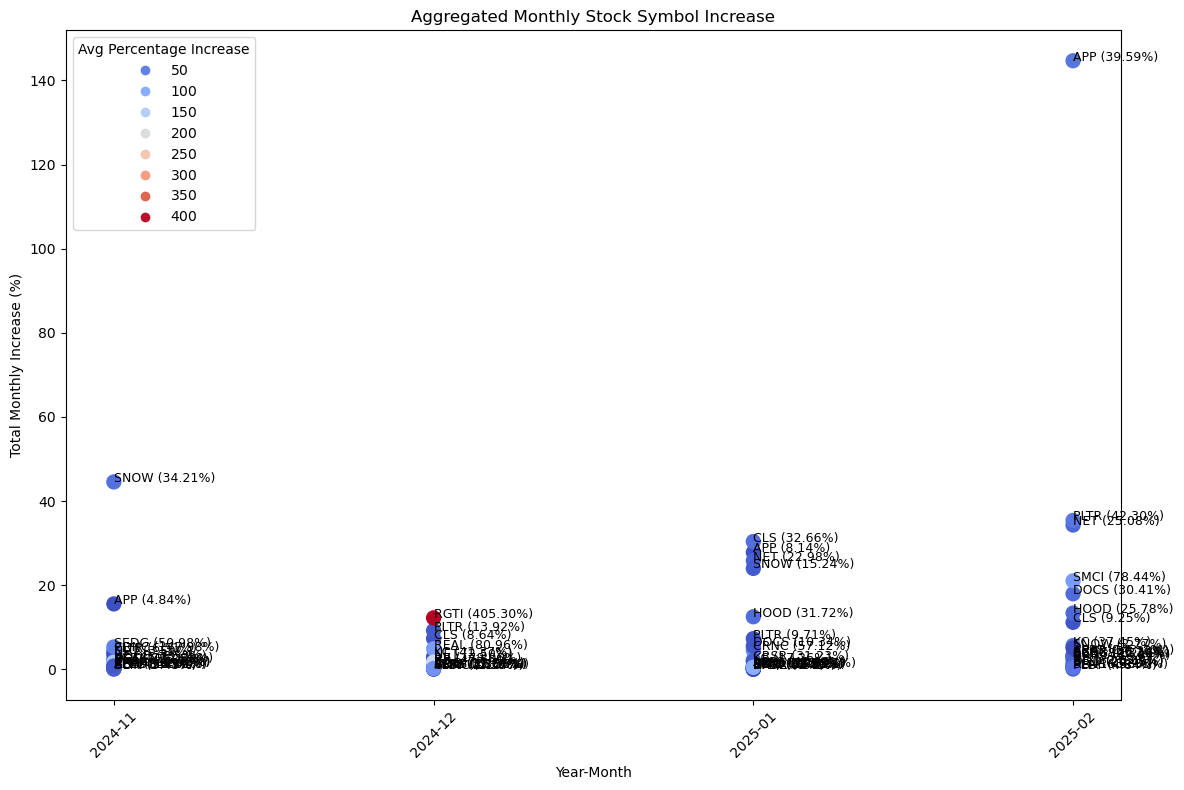

In [15]:
# Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot
scatter = ax.scatter(
    agg_df['year_month_str'],
    agg_df['total_monthly_increase'],
    c=agg_df['avg_percentage_increase'],
    cmap='coolwarm',
    s=100
)

# Add labels
for i, row in agg_df.iterrows():
    ax.text(row['year_month_str'], row['total_monthly_increase'], f"{row['symbol']} ({row['avg_percentage_increase']:.2f}%)", fontsize=9)

# Formatting
ax.set_xticks(agg_df['year_month_str'].cat.categories)
ax.set_xticklabels(agg_df['year_month_str'].cat.categories, rotation=45)
ax.set_title('Aggregated Monthly Stock Symbol Increase')
ax.set_xlabel('Year-Month')
ax.set_ylabel('Total Monthly Increase (%)')
ax.legend(*scatter.legend_elements(), title='Avg Percentage Increase')

plt.tight_layout()
plt.show()

In [16]:
import numpy as np

#print(agg_df)
# Group the data by symbol and month, then calculate the mean percentage increase
grouped = agg_df.groupby(['symbol', 'year_month_str'],observed=False)['avg_percentage_increase'].mean().unstack()

# Fill NaN values with 0
grouped = grouped.fillna(0)

# Calculate the overall percentage increase for each symbol
overall_increase = grouped.sum(axis=1)

#print(grouped)
# Sort the DataFrame by the total percentage increase (sum across all months)
#sorted_df = grouped.sort_values(by=grouped.columns.tolist(), ascending=True)
sorted_df = grouped.loc[overall_increase.sort_values().index]
print(sorted_df)

year_month_str     2024-11     2024-12     2025-01     2025-02
symbol                                                        
BFLY              7.868853    0.000000    0.503778   20.454544
DOCS              2.852710    0.000000   10.343534   30.406094
CLS               0.000000    8.639364   32.663588    9.248842
SNOW             34.213756    0.000000   15.237128    2.772002
APP               4.844484    0.000000    8.136812   39.593367
NET               3.590328    2.503567   22.978490   25.080392
DDD               0.000000   17.562725   12.499995   25.668444
RXRX             12.759174    0.000000    0.416085   45.241376
BLIN              5.454540   31.666665   23.749999    0.000000
MVIS              0.000000   45.555553   16.911766    0.000000
PLBY             22.123894    2.097909   34.931505    4.838711
HOOD              6.526672    0.000000   31.719073   25.780341
PLTR              6.510007   13.917756    9.708731   42.297596
SEDG             50.979455    0.000000    0.000000   22

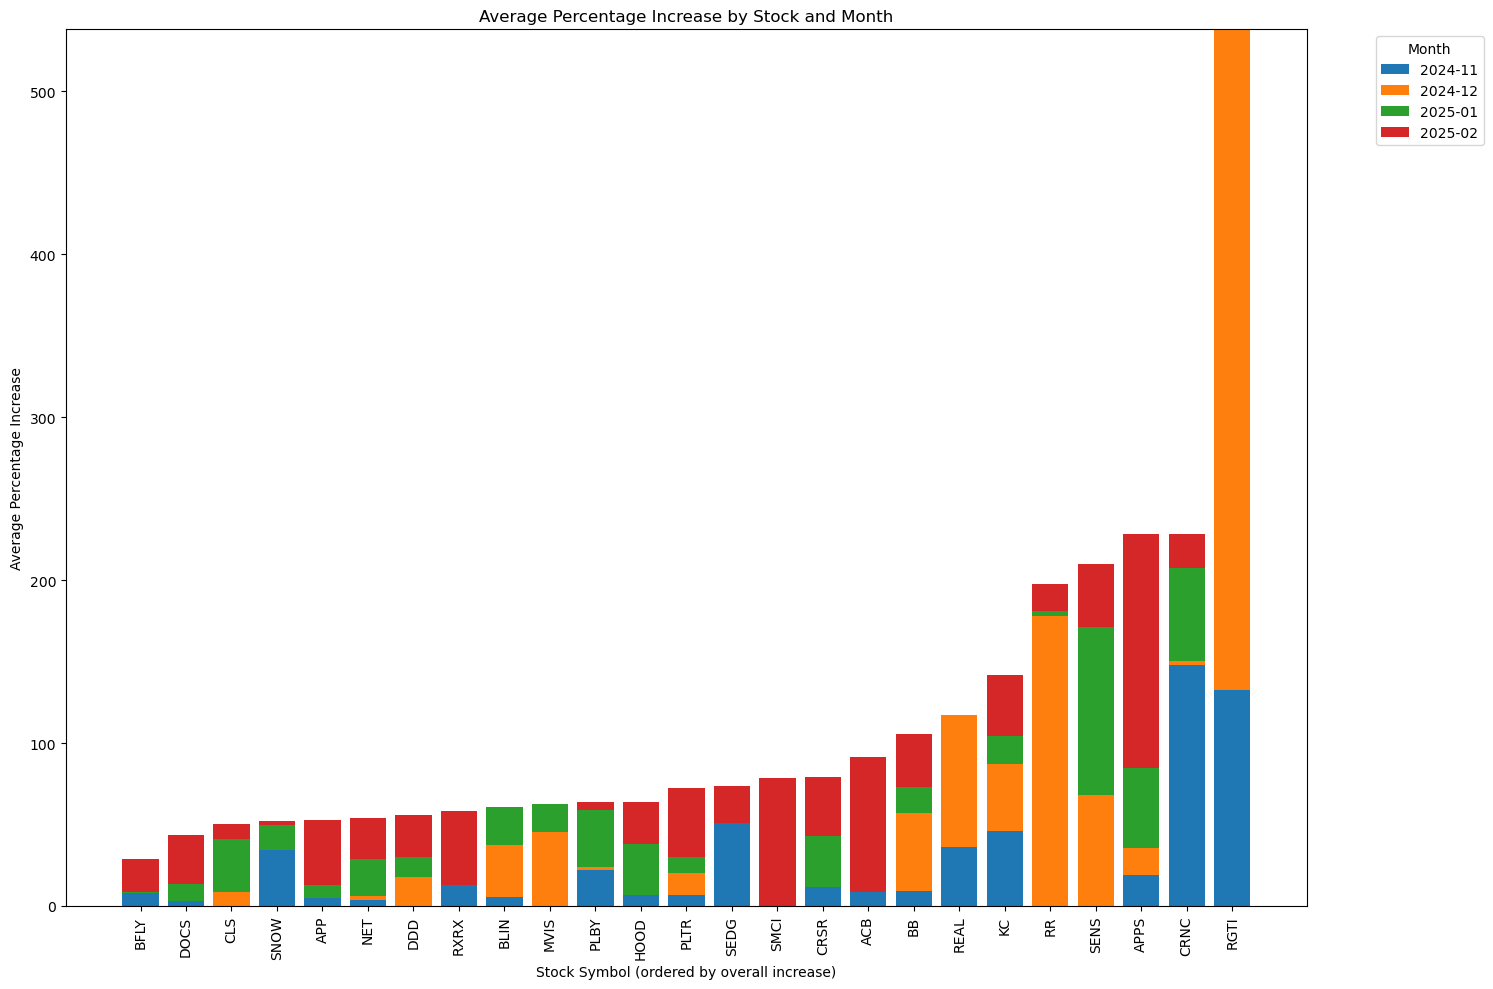

In [17]:
# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(15, 10))

bottom = np.zeros(len(sorted_df))

for month in sorted_df.columns:
    ax.bar(sorted_df.index, sorted_df[month], bottom=bottom, label=month)
    bottom += sorted_df[month]

# Customize the chart
ax.set_title('Average Percentage Increase by Stock and Month')
ax.set_xlabel('Stock Symbol (ordered by overall increase)')
ax.set_ylabel('Average Percentage Increase')
ax.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Adjust layout to prevent cutting off labels
plt.tight_layout()

# Show the plot
plt.show()